In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Load Raw BindingDB Dataset

This cell loads the raw BindingDB dataset from its CSV file into a pandas DataFrame. This is the starting point for processing the BindingDB data.

In [ ]:
# Define the path to the raw BindingDB CSV file
bindingdb_raw_csv_path = '/content/ezh2_bindingdb_measurements.csv'

# Load the raw BindingDB data
df_bindingdb_raw = pd.read_csv(bindingdb_raw_csv_path)

print(f"Raw BindingDB DataFrame shape: {df_bindingdb_raw.shape}")
display(df_bindingdb_raw.head())

Raw BindingDB DataFrame shape: (2327, 5)


,chembl_id,canonical_smiles,IC50,IC50_unit,pIC50
0,172020,Cc1cc(C)c(CNC(=O)c2cc(-c3ccc(CN4CCOCC4)nc3)cc(...,10.10,nM,7.995679
1,172023,Cc1cc(C)c(CNC(=O)c2cc(-c3ccc(CN(C)C)cc3)cc(N(C...,7.21,nM,8.142065
2,172029,Cc1cc(C)c(CNC(=O)c2cc(-c3ccc(CN(C)C)nc3)cc(N(C...,16.25,nM,7.789147
3,172030,CCN(c1cc(-c2ccc(CN3CCOCC3)cc2)cc(C(=O)NCc2c(C)...,8.45,nM,8.073143
4,172031,CC(=O)N[C@H]1CC[C@H](N(C)c2cc(-c3cnn(CCN4CCOCC...,54.90,nM,7.260428


### Clean BindingDB Dataset

This section focuses on cleaning the raw BindingDB dataset. The cleaning steps generally include:

1.  **Column Renaming and Selection**: Standardizing column names and selecting relevant columns.
2.  **Handling Missing Values**: Removing rows with critical missing information.
3.  **Data Type Conversion**: Ensuring numerical data is in the correct format.
4.  **Standardizing Activity Units**: Converting activity values (e.g., IC50) to a consistent scale like pIC50.
5.  **Removing Duplicates**: Identifying and removing duplicate entries based on `canonical_smiles`.


In [ ]:
# Make a copy to avoid modifying the original raw dataframe
df_bindingdb_cleaned = df_bindingdb_raw.copy()

# Rename columns for consistency if necessary (assuming 'chembl_id' and 'canonical_smiles' are already present and correctly named)
# If there are specific columns to rename, add them here. For example:
# df_bindingdb_cleaned = df_bindingdb_cleaned.rename(columns={'Original_SMILES_Column': 'canonical_smiles', 'Original_IC50_Column': 'IC50'})

# Drop rows where 'canonical_smiles' or 'IC50' are missing, as these are crucial for analysis
df_bindingdb_cleaned.dropna(subset=['canonical_smiles', 'IC50'], inplace=True)

# Convert IC50 to numeric, coercing errors to NaN
df_bindingdb_cleaned['IC50'] = pd.to_numeric(df_bindingdb_cleaned['IC50'], errors='coerce')

# Drop rows where IC50 became NaN after conversion
df_bindingdb_cleaned.dropna(subset=['IC50'], inplace=True)

# Filter out entries where IC50 is 0 or non-positive, as pIC50 cannot be calculated for these
df_bindingdb_cleaned = df_bindingdb_cleaned[df_bindingdb_cleaned['IC50'] > 0]

# Calculate pIC50 if it's not already present or needs recalculation
# Assuming IC50 is in nM, convert to M for pIC50 calculation (-log10(IC50 * 1e-9))
if 'pIC50' not in df_bindingdb_cleaned.columns or df_bindingdb_cleaned['pIC50'].isnull().any():
    df_bindingdb_cleaned['pIC50'] = -np.log10(df_bindingdb_cleaned['IC50'] * 1e-9)

# Remove duplicate compounds based on 'canonical_smiles'
duplicate_rows_bindingdb = df_bindingdb_cleaned[df_bindingdb_cleaned.duplicated(subset=['canonical_smiles'], keep=False)]
print(f"Number of duplicate compounds in BindingDB: {len(duplicate_rows_bindingdb)}")
df_bindingdb_cleaned.drop_duplicates(subset=['canonical_smiles'], inplace=True)

print(f"Cleaned BindingDB DataFrame shape: {df_bindingdb_cleaned.shape}")
display(df_bindingdb_cleaned.head())

Number of duplicate compounds in BindingDB: 127
Cleaned BindingDB DataFrame shape: (2263, 5)


,chembl_id,canonical_smiles,IC50,IC50_unit,pIC50
0,172020,Cc1cc(C)c(CNC(=O)c2cc(-c3ccc(CN4CCOCC4)nc3)cc(...,10.10,nM,7.995679
1,172023,Cc1cc(C)c(CNC(=O)c2cc(-c3ccc(CN(C)C)cc3)cc(N(C...,7.21,nM,8.142065
2,172029,Cc1cc(C)c(CNC(=O)c2cc(-c3ccc(CN(C)C)nc3)cc(N(C...,16.25,nM,7.789147
3,172030,CCN(c1cc(-c2ccc(CN3CCOCC3)cc2)cc(C(=O)NCc2c(C)...,8.45,nM,8.073143
4,172031,CC(=O)N[C@H]1CC[C@H](N(C)c2cc(-c3cnn(CCN4CCOCC...,54.90,nM,7.260428


### Combine Cleaned Datasets

Now that both the ChEMBL (represented by `df_cleaned`) and BindingDB (`df_bindingdb_cleaned`) datasets have been cleaned, the next step is to combine them into a single DataFrame. This unified dataset will be used for further analysis and model training.

In [ ]:
# Load the cleaned ChEMBL dataframe if it's not already in memory
# Assuming 'cleaned_csv_path' points to the saved ChEMBL data
# If df_cleaned is already loaded, you can skip this step or ensure it's up-to-date.
if 'df_cleaned' not in locals() or df_cleaned.empty:
    try:
        df_cleaned = pd.read_csv(cleaned_csv_path)
        print(f"Loaded df_cleaned with shape: {df_cleaned.shape}")
    except FileNotFoundError:
        print(f"Error: ChEMBL cleaned data not found at {cleaned_csv_path}. Please ensure it has been saved.")
        # You might want to generate code to clean chembl data here if it's missing.

# Combine the cleaned ChEMBL and BindingDB dataframes
df_combined = pd.concat([df_cleaned, df_bindingdb_cleaned], ignore_index=True)

print(f"Combined DataFrame shape: {df_combined.shape}")
display(df_combined.head())

Combined DataFrame shape: (3709, 5)


,chembl_id,canonical_smiles,IC50,IC50_unit,pIC50
0,CHEMBL5563355,Cc1cc(C)c(CNC(=O)c2cc(-c3ccc(-c4nc5c(C(N)=O)cc...,0.0030,/s,11.522879
1,CHEMBL3414621,CCN(c1cc(-c2ccc(CN3CCOCC3)cc2)cc(C(=O)NCc2c(C)...,0.0040,/s,11.397940
2,CHEMBL5555822,CCn1ncc2c(C(=O)NCc3c(C)cc(C)[nH]c3=O)cc(-c3ccc...,0.0040,/s,11.397940
3,CHEMBL5206842,COC1CN([C@H]2CC[C@H]([C@@H](C)c3sc4c(c3C)C(=O)...,0.0097,nM,11.013228
4,CHEMBL5188827,CCCc1cc(C)[nH]c(=O)c1CNC(=O)c1cc(-c2ccc(N3CCOC...,0.0100,nM,11.000000


### Combine Cleaned ChEMBL and BindingDB Data

Now that both the `df_cleaned` (ChEMBL) and `df_bindingdb_cleaned` (BindingDB) datasets are prepared, we will combine them into a single `df_combined` DataFrame for unified analysis.

In [ ]:
# Combine the cleaned ChEMBL and BindingDB dataframes
df_combined = pd.concat([df_cleaned, df_bindingdb_cleaned], ignore_index=True)

print(f"Combined DataFrame shape: {df_combined.shape}")
display(df_combined.head())

Combined DataFrame shape: (3709, 5)


,chembl_id,canonical_smiles,IC50,IC50_unit,pIC50
0,CHEMBL5563355,Cc1cc(C)c(CNC(=O)c2cc(-c3ccc(-c4nc5c(C(N)=O)cc...,0.0030,/s,11.522879
1,CHEMBL3414621,CCN(c1cc(-c2ccc(CN3CCOCC3)cc2)cc(C(=O)NCc2c(C)...,0.0040,/s,11.397940
2,CHEMBL5555822,CCn1ncc2c(C(=O)NCc3c(C)cc(C)[nH]c3=O)cc(-c3ccc...,0.0040,/s,11.397940
3,CHEMBL5206842,COC1CN([C@H]2CC[C@H]([C@@H](C)c3sc4c(c3C)C(=O)...,0.0097,nM,11.013228
4,CHEMBL5188827,CCCc1cc(C)[nH]c(=O)c1CNC(=O)c1cc(-c2ccc(N3CCOC...,0.0100,nM,11.000000


In [ ]:
combined_csv_path = 'ezh2_combined_dataset.csv'
df_combined.to_csv(combined_csv_path, index=False)

print(f"df_combined saved to {combined_csv_path}")

df_combined saved to ezh2_combined_dataset.csv


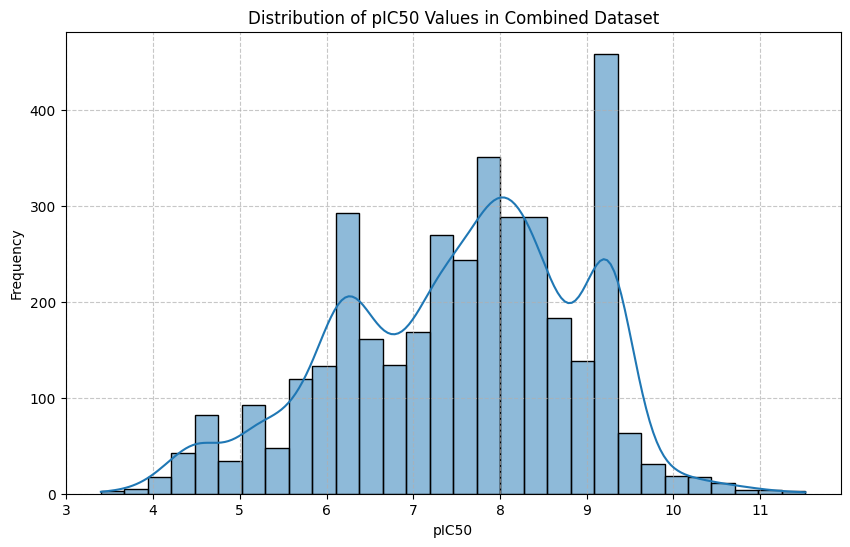

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_combined['pIC50'], bins=30, kde=True)
plt.title('Distribution of pIC50 Values in Combined Dataset')
plt.xlabel('pIC50')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

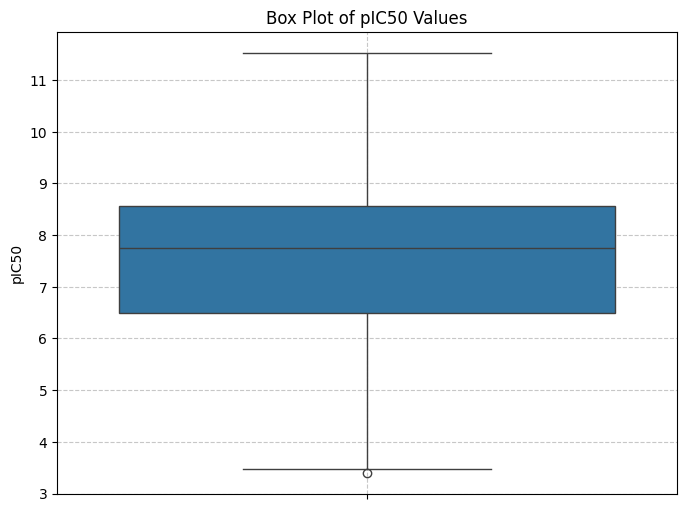

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_combined['pIC50'])
plt.title('Box Plot of pIC50 Values')
plt.ylabel('pIC50')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

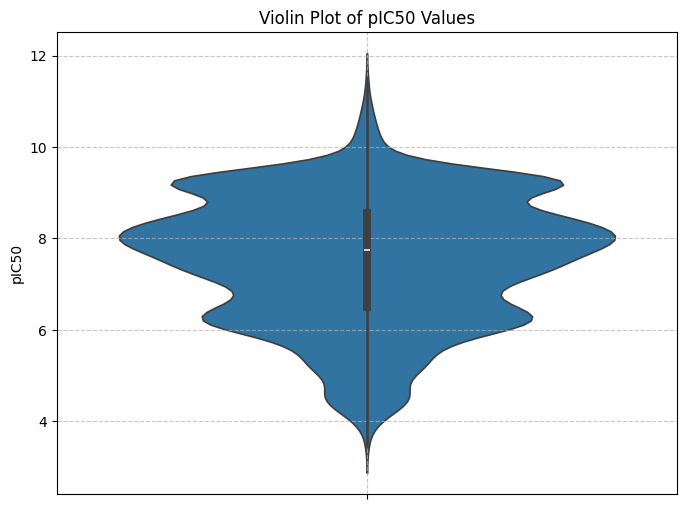

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(y=df_combined['pIC50'])
plt.title('Violin Plot of pIC50 Values')
plt.ylabel('pIC50')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

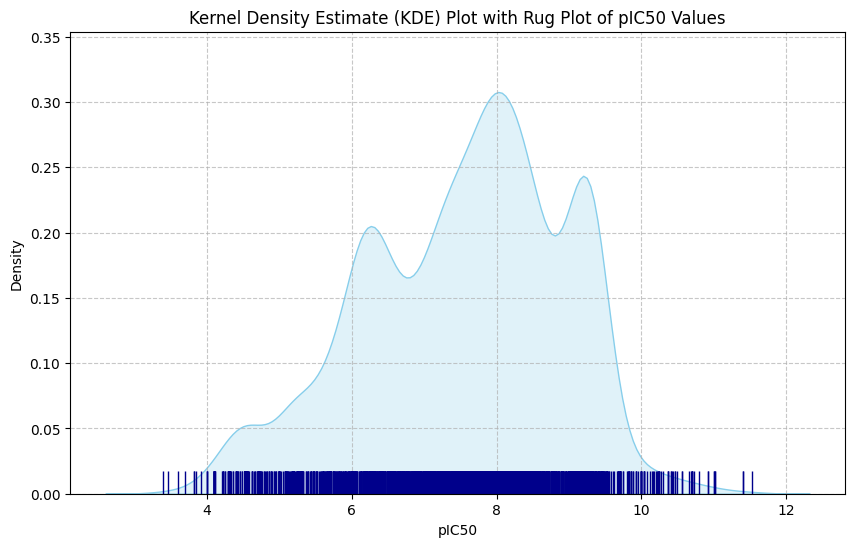

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_combined['pIC50'], fill=True, color='skyblue')
sns.rugplot(df_combined['pIC50'], color='darkblue', height=0.05) # Add a rug plot to show individual data points
plt.title('Kernel Density Estimate (KDE) Plot with Rug Plot of pIC50 Values')
plt.xlabel('pIC50')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import pandas as pd
df = pd.read_excel("/content/ezh2_combined_dataset_nM_only.xlsx")
print(df.head())






       chembl_id                                   canonical_smiles  \
0  CHEMBL5206842  COC1CN([C@H]2CC[C@H]([C@@H](C)c3sc4c(c3C)C(=O)...   
1  CHEMBL5188827  CCCc1cc(C)[nH]c(=O)c1CNC(=O)c1cc(-c2ccc(N3CCOC...   
2  CHEMBL5172110  CSc1cc(C)[nH]c(=O)c1CN1CCc2c(Cl)c3c(c(C)c2C1=O...   
3  CHEMBL3264787  CC1(C)CC(NC(=O)c2ccc(Oc3cccc(-c4ccnnc4)c3C#N)c...   
4  CHEMBL5178022  CSc1cc(C)[nH]c(=O)c1CNC(=O)c1cc(Cl)c2c(c1C)O[C...   

   original_IC50 original_IC50_unit  original_pIC50  IC50_nM IC50_unit  \
0         0.0097                 nM       11.013228   0.0097        nM   
1         0.0100                 nM       11.000000   0.0100        nM   
2         0.0280                 nM       10.552842   0.0280        nM   
3         0.0320                 nM       10.494850   0.0320        nM   
4         0.0380                 nM       10.420216   0.0380        nM   

   pIC50_normalized normalization_status       normalization_note  
0         11.013228            converted  Already reported i

In [ ]:
frame = df[["canonical_smiles", "IC50_nM"]]
print(df.head())

                                    canonical_smiles  IC50_nM
0  COC1CN([C@H]2CC[C@H]([C@@H](C)c3sc4c(c3C)C(=O)...   0.0097
1  CCCc1cc(C)[nH]c(=O)c1CNC(=O)c1cc(-c2ccc(N3CCOC...   0.0100
2  CSc1cc(C)[nH]c(=O)c1CN1CCc2c(Cl)c3c(c(C)c2C1=O...   0.0280
3  CC1(C)CC(NC(=O)c2ccc(Oc3cccc(-c4ccnnc4)c3C#N)c...   0.0320
4  CSc1cc(C)[nH]c(=O)c1CNC(=O)c1cc(Cl)c2c(c1C)O[C...   0.0380


In [ ]:
frame = df[["canonical_smiles", "IC50_nM"]]
display(frame.head())

,canonical_smiles,IC50_nM
0,COC1CN([C@H]2CC[C@H]([C@@H](C)c3sc4c(c3C)C(=O)...,0.0097
1,CCCc1cc(C)[nH]c(=O)c1CNC(=O)c1cc(-c2ccc(N3CCOC...,0.0100
2,CSc1cc(C)[nH]c(=O)c1CN1CCc2c(Cl)c3c(c(C)c2C1=O...,0.0280
3,CC1(C)CC(NC(=O)c2ccc(Oc3cccc(-c4ccnnc4)c3C#N)c...,0.0320
4,CSc1cc(C)[nH]c(=O)c1CNC(=O)c1cc(Cl)c2c(c1C)O[C...,0.0380


In [ ]:
# View column names
print(df.columns)


Index(['chembl_id', 'canonical_smiles', 'original_IC50', 'original_IC50_unit',
       'original_pIC50', 'IC50_nM', 'IC50_unit', 'pIC50_normalized',
       'normalization_status', 'normalization_note'],
      dtype='object')


In [ ]:
display(df['pIC50_normalized'].describe())